In [228]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [229]:
df_klaim = pd.read_csv('dataset/Data_Klaim.csv')
df_polis = pd.read_csv('dataset/Data_Polis.csv')
df_klaim.head(2)

,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6143947.68,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,82309522.45,Malaysia


In [230]:
df_klaim.describe()

,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi
count,4.627000e+03,4.627000e+03
mean,5.502892e+07,5.994940e+07
std,1.319527e+08,1.597838e+08
min,0.000000e+00,0.000000e+00
25%,2.274009e+06,2.720210e+06
50%,1.446790e+07,1.587100e+07
75%,5.107209e+07,5.423067e+07
max,2.197500e+09,3.892810e+09


In [231]:
df_polis.head(3)

,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili
0,POL-0001,M-003,M,19640811,20140603,JAKARTA
1,POL-0002,M-003,M,19710730,20140603,JAKARTA
2,POL-0003,M-001,M,19790821,20160808,JAKARTA


### 1. Data Cleaning

In [232]:
#checking missing value df_klaim
(df_klaim.isnull().sum() / len(df_klaim)) * 100

Claim ID                         0.000000
Nomor Polis                      0.000000
Reimburse/Cashless               0.000000
Inpatient/Outpatient             0.799654
ICD Diagnosis                    0.129674
ICD Description                  0.129674
Status Klaim                     0.000000
Tanggal Pembayaran Klaim         0.799654
Tanggal Pasien Masuk RS          0.000000
Tanggal Pasien Keluar RS         0.000000
Nominal Klaim Yang Disetujui     0.000000
Nominal Biaya RS Yang Terjadi    0.000000
Lokasi RS                        0.151286
dtype: float64

In [233]:
df_klaim.isna().sum()

Claim ID                          0
Nomor Polis                       0
Reimburse/Cashless                0
Inpatient/Outpatient             37
ICD Diagnosis                     6
ICD Description                   6
Status Klaim                      0
Tanggal Pembayaran Klaim         37
Tanggal Pasien Masuk RS           0
Tanggal Pasien Keluar RS          0
Nominal Klaim Yang Disetujui      0
Nominal Biaya RS Yang Terjadi     0
Lokasi RS                         7
dtype: int64

In [234]:
df_klaim[df_klaim["Tanggal Pembayaran Klaim"].isna()].head(4)


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-06,2024-06-06,1.389364e+08,1.389364e+08,Singapore
5,C-0006-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-07-18,2024-07-18,1.360160e+08,1.368552e+08,Singapore
6,C-0007-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-27,2024-06-27,1.341925e+08,1.347333e+08,Singapore
7,C-0008-M,POL-0566,R,OP,C90.0,Multiple myeloma,PAID,NaN,2024-06-19,2024-06-19,5.398718e+08,3.164563e+08,Singapore


In [235]:
#mengambil kolom yang memiliki baris null di df_klaim
kolom_null_klaim = [x for x in df_klaim.columns if df_klaim[x].isna().any()]
kolom_null_klaim    

['Inpatient/Outpatient',
 'ICD Diagnosis',
 'ICD Description',
 'Tanggal Pembayaran Klaim',
 'Lokasi RS']

In [236]:
#checking missing value df_polis
df_polis.isna().sum()

Nomor Polis              0
Plan Code                0
Gender                   0
Tanggal Lahir            0
Tanggal Efektif Polis    0
Domisili                 0
dtype: int64

In [237]:
#checking duplcated value
df_polis.duplicated().sum()
df_klaim.duplicated().sum()

np.int64(0)

Simulasi mengatasi missing value:
- 'Tanggal Pembayaran klaim' -> Imputasi dengan "Median Lag" -> Ambil semua data yang lengkap (punya tanggal keluar RS & tanggal bayar).
Hitung selisih hari (Lag) = Tanggal Pembayaran - Tanggal Keluar RS

- 'Inpatient/Outpatient' -> diisi berdasarkan selisih tgl keluar - tgl masuk -> kalau > 0 maka Inpatient, kalo = 0 maka outpatient

- 'ICD Diagnosis'  -> Standar WHO ICD-10 (International Classification of Diseases) isi dgn 'R69' artinya Unknown and unspecified causes of morbidity (Penyebab kesakitan yang tidak diketahui/tidak spesifik).

- 'ICD Description' -> diisi "Unknown". Ini membuat model mengerti bahwa "tidak ada diagnosa" adalah sebuah kategori risiko tersendiri.

-'lokasi RS' -> isi dengan 'OTHER'

In [238]:
df_klaim.dtypes

Claim ID                             str
Nomor Polis                          str
Reimburse/Cashless                   str
Inpatient/Outpatient                 str
ICD Diagnosis                        str
ICD Description                      str
Status Klaim                         str
Tanggal Pembayaran Klaim             str
Tanggal Pasien Masuk RS              str
Tanggal Pasien Keluar RS             str
Nominal Klaim Yang Disetujui     float64
Nominal Biaya RS Yang Terjadi    float64
Lokasi RS                            str
dtype: object

In [239]:
#SOLVING MISSING VALUE
df_klaim_cleaned = df_klaim.copy()

'''Pastikan kolom tanggal bertipe datetime, bukan object/string'''
cols_date = ['Tanggal Pembayaran Klaim', 'Tanggal Pasien Masuk RS', 'Tanggal Pasien Keluar RS']
for col in cols_date:
    df_klaim_cleaned[col] = pd.to_datetime(df_klaim_cleaned[col], errors='coerce')

# 1. IMPUTASI TANGGAL PEMBAYARAN KLAIM (MEDIAN LAG)
''' a. Hitung Lag (selisih hari) pada data yang LENGKAP saja '''
valid_data = df_klaim_cleaned.dropna(subset=['Tanggal Pembayaran Klaim', 'Tanggal Pasien Keluar RS'])
lag_days = (valid_data['Tanggal Pembayaran Klaim'] - valid_data['Tanggal Pasien Keluar RS']).dt.days

''' b. Ambil nilai tengah (Median)'''
median_lag = lag_days.median()
print(f"Median Lag yang ditemukan: {median_lag} hari")

''' c. Isi Tanggal Pembayaran yang NULL = Tanggal Keluar + Median Lag '''
mask_null_pay = df_klaim_cleaned['Tanggal Pembayaran Klaim'].isnull()
df_klaim_cleaned.loc[mask_null_pay, 'Tanggal Pembayaran Klaim'] = (
    df_klaim_cleaned.loc[mask_null_pay, 'Tanggal Pasien Keluar RS'] + pd.to_timedelta(median_lag, unit='D')
)

# 2. IMPUTASI INPATIENT/OUTPATIENT 
# Hitung durasi rawat (Keluar - Masuk)
durasi_rawat = (df_klaim_cleaned['Tanggal Pasien Keluar RS'] - df_klaim_cleaned['Tanggal Pasien Masuk RS']).dt.days

# Logic: Jika durasi > 0 -> Inpatient, Jika 0 -> Outpatient
# isi yang NULL saja
mask_null_io = df_klaim_cleaned['Inpatient/Outpatient'].isnull()
df_klaim_cleaned.loc[mask_null_io, 'Inpatient/Outpatient'] = np.where(
    durasi_rawat[mask_null_io] > 0, 'Inpatient', 'Outpatient'
)

# 3. IMPUTASI KATEGORIKAL (ICD & LOKASI)
# ICD Diagnosis -> R69 (Unknown Cause)
df_klaim_cleaned['ICD Diagnosis'] = df_klaim_cleaned['ICD Diagnosis'].fillna('R69')

# ICD Description -> Unknown
df_klaim_cleaned['ICD Description'] = df_klaim_cleaned['ICD Description'].fillna('Unknown')

# Lokasi RS -> OTHER
df_klaim_cleaned['Lokasi RS'] = df_klaim_cleaned['Lokasi RS'].fillna('OTHER')

print("\nSisa Missing Value setelah cleaning:")
print(df_klaim_cleaned.isnull().sum())


Median Lag yang ditemukan: 61.0 hari

Sisa Missing Value setelah cleaning:
Claim ID                         0
Nomor Polis                      0
Reimburse/Cashless               0
Inpatient/Outpatient             0
ICD Diagnosis                    0
ICD Description                  0
Status Klaim                     0
Tanggal Pembayaran Klaim         0
Tanggal Pasien Masuk RS          0
Tanggal Pasien Keluar RS         0
Nominal Klaim Yang Disetujui     0
Nominal Biaya RS Yang Terjadi    0
Lokasi RS                        0
dtype: int64


In [240]:
print(f"Cek tipe data: \n{df_klaim_cleaned.dtypes}")
print(f"\nCek duplikat: \n{df_klaim_cleaned.duplicated().sum()}")

Cek tipe data: 
Claim ID                                    str
Nomor Polis                                 str
Reimburse/Cashless                          str
Inpatient/Outpatient                        str
ICD Diagnosis                               str
ICD Description                             str
Status Klaim                                str
Tanggal Pembayaran Klaim         datetime64[us]
Tanggal Pasien Masuk RS          datetime64[us]
Tanggal Pasien Keluar RS         datetime64[us]
Nominal Klaim Yang Disetujui            float64
Nominal Biaya RS Yang Terjadi           float64
Lokasi RS                                   str
dtype: object

Cek duplikat: 
0


In [241]:
df_polis.info()

<class 'pandas.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Nomor Polis            4096 non-null   str  
 1   Plan Code              4096 non-null   str  
 2   Gender                 4096 non-null   str  
 3   Tanggal Lahir          4096 non-null   int64
 4   Tanggal Efektif Polis  4096 non-null   int64
 5   Domisili               4096 non-null   str  
dtypes: int64(2), str(4)
memory usage: 192.1 KB


In [242]:
df_polis_cleaned = df_polis.copy()

In [243]:
date_cols = ["Tanggal Lahir", "Tanggal Efektif Polis"]

for col in date_cols:
    df_polis_cleaned[col] = pd.to_datetime(df_polis_cleaned[col], format="%Y%m%d", errors="coerce")

df_polis_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Nomor Polis            4096 non-null   str           
 1   Plan Code              4096 non-null   str           
 2   Gender                 4096 non-null   str           
 3   Tanggal Lahir          4096 non-null   datetime64[us]
 4   Tanggal Efektif Polis  4096 non-null   datetime64[us]
 5   Domisili               4096 non-null   str           
dtypes: datetime64[us](2), str(4)
memory usage: 192.1 KB


### 2. EDA

In [244]:
# Merge: Left join agar semua data klaim terambil, ditambah info polisnya
df_final = df_klaim_cleaned.merge(df_polis_cleaned, on='Nomor Polis', how='left')

In [245]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 4627 entries, 0 to 4626
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Claim ID                       4627 non-null   str           
 1   Nomor Polis                    4627 non-null   str           
 2   Reimburse/Cashless             4627 non-null   str           
 3   Inpatient/Outpatient           4627 non-null   str           
 4   ICD Diagnosis                  4627 non-null   str           
 5   ICD Description                4627 non-null   str           
 6   Status Klaim                   4627 non-null   str           
 7   Tanggal Pembayaran Klaim       4627 non-null   datetime64[us]
 8   Tanggal Pasien Masuk RS        4627 non-null   datetime64[us]
 9   Tanggal Pasien Keluar RS       4627 non-null   datetime64[us]
 10  Nominal Klaim Yang Disetujui   4627 non-null   float64       
 11  Nominal Biaya RS Yang Terjad

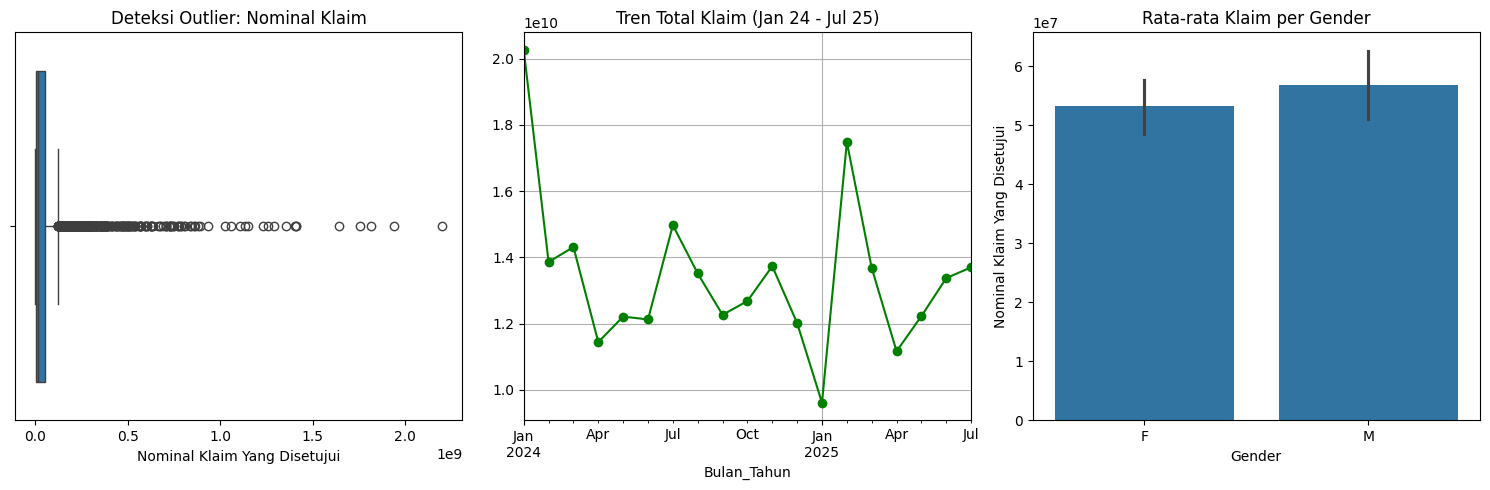

In [246]:
#Identifikasi Outlier & Visualisasi Tren
#Fokus: Melihat distribusi data "uang" dan memvalidasi tren kenaikan.

plt.figure(figsize=(15, 5))

# A. Deteksi Outlier pada Nominal Klaim (Boxplot)
plt.subplot(1, 3, 1)
sns.boxplot(x=df_final['Nominal Klaim Yang Disetujui'])
plt.title('Deteksi Outlier: Nominal Klaim')

# B. Tren Total Klaim per Bulan (Line Plot)
# Validasi kenaikan 25.5%
df_final['Bulan_Tahun'] = df_final['Tanggal Pasien Masuk RS'].dt.to_period('M')
trend_data = df_final.groupby('Bulan_Tahun')['Nominal Klaim Yang Disetujui'].sum()

plt.subplot(1, 3, 2)
trend_data.plot(kind='line', marker='o', color='green')
plt.title('Tren Total Klaim (Jan 24 - Jul 25)')
plt.grid(True)

# C. Hubungan Gender vs Rata-rata Klaim (Bar Plot)
plt.subplot(1, 3, 3)
sns.barplot(data=df_final, x='Gender', y='Nominal Klaim Yang Disetujui', estimator=np.mean)
plt.title('Rata-rata Klaim per Gender')

plt.tight_layout()
plt.show()

1. Outlier:  banyak outliers = klaim jumbo. Jangan dihapus, tapi di-log transform tuk Menormalkan Distribusi dan Meredam Skala Ekstrem. tidak dihapus karena:

    - Data Valid, Bukan Error: Dalam asuransi, klaim jumbo (titik hitam di boxplot) adalah kejadian nyata, bukan kesalahan input.

    - Risiko Sebenarnya: Menghapusnya akan membuat analisis bias. ini akan meremehkan risiko finansial perusahaan karena "membutakan" model terhadap potensi kerugian besar yang sewaktu-waktu bisa terjadi.

2. Tren: grafik garis menanjak di 2025 (sesuai dgn deskripsi kondisi)

3. Faktor: Pria dan Wanita tdk memiliki beban klaim yang berbeda signifikan.

### 3. Feature Engineering & Analysis

#### 3A. Frequency Analysis

In [247]:
### 3.2 Frequency Analysis Per Policy
# Rumus: (Tgl Masuk - Tgl Lahir) / 365
df_final['Usia'] = (df_final['Tanggal Pasien Masuk RS'] - df_final['Tanggal Lahir']).dt.days // 365

# 2. Hitung Durasi Rawat
# Rumus: Tgl Keluar - Tgl Masuk
df_final['Durasi_Rawat'] = (df_final['Tanggal Pasien Keluar RS'] - df_final['Tanggal Pasien Masuk RS']).dt.days

# 3. Ekstrak Waktu (Penting untuk Time Series Forecasting)
df_final['Bulan'] = df_final['Tanggal Pasien Masuk RS'].dt.month
df_final['Tahun'] = df_final['Tanggal Pasien Masuk RS'].dt.year
df_final['Kuartal'] = df_final['Tanggal Pasien Masuk RS'].dt.quarter

# 4. Feature Binning : Kelompokkan Usia
# 0-18: Anak, 19-60: Dewasa, >60: Lansia
df_final['Kategori_Usia'] = pd.cut(df_final['Usia'], bins=[0, 18, 60, 100], labels=['Anak', 'Dewasa', 'Lansia'])

# 5. Hitung Tenure Polis
df_final['Tenure_Polis'] = (df_final['Tanggal Pasien Masuk RS'] - df_final['Tanggal Efektif Polis']).dt.days // 30


In [248]:
# Feature Creation - Membuat Fitur Baru dari Data Temporal

# Agregasi per polis 
df_EDA_freq = df_final.copy()
freq_per_polis = df_EDA_freq.groupby('Nomor Polis').agg(
    Frekuensi       = ('Claim ID', 'count'),
    Plan_Code       = ('Plan Code', 'first'),
    Domisili        = ('Domisili', 'first'),
    Usia            = ('Usia', 'first'),
    Tenure_Polis    = ('Tenure_Polis', 'first'),
    Jumlah_ICD_Unik = ('ICD Diagnosis', 'nunique')
).reset_index()

# Menghapus tenure <=0 (tidak Valid)
freq_per_polis = freq_per_polis[freq_per_polis['Tenure_Polis'] > 0]

# Kategori Frekuensi
freq_per_polis['Kategori_Frekuensi'] = pd.cut(freq_per_polis['Frekuensi'], bins=[0, 1, 5, 100],labels=['Low', 'Medium','High'])

# Convert tenure ke tahun
freq_per_polis['Tenure_Tahun'] = freq_per_polis['Tenure_Polis'] / 12

# Buat Claim Rate (klaim per tahun)
freq_per_polis['Claim_Rate'] = (
    freq_per_polis['Frekuensi'] / freq_per_polis['Tenure_Tahun']
)

print(f"\nTotal Polis: {len(freq_per_polis)}")
print(f"Rata-rata Frekuensi: {freq_per_polis['Frekuensi'].mean():.2f}")



Total Polis: 1210
Rata-rata Frekuensi: 3.82


In [249]:
freq_per_polis[['Tenure_Tahun','Claim_Rate']].describe()

,Tenure_Tahun,Claim_Rate
count,1210.000000,1210.000000
mean,9.921419,0.393942
std,1.780112,0.963662
min,6.083333,0.073620
25%,8.500000,0.118812
50%,9.916667,0.225708
75%,11.416667,0.395604
max,13.666667,18.372414


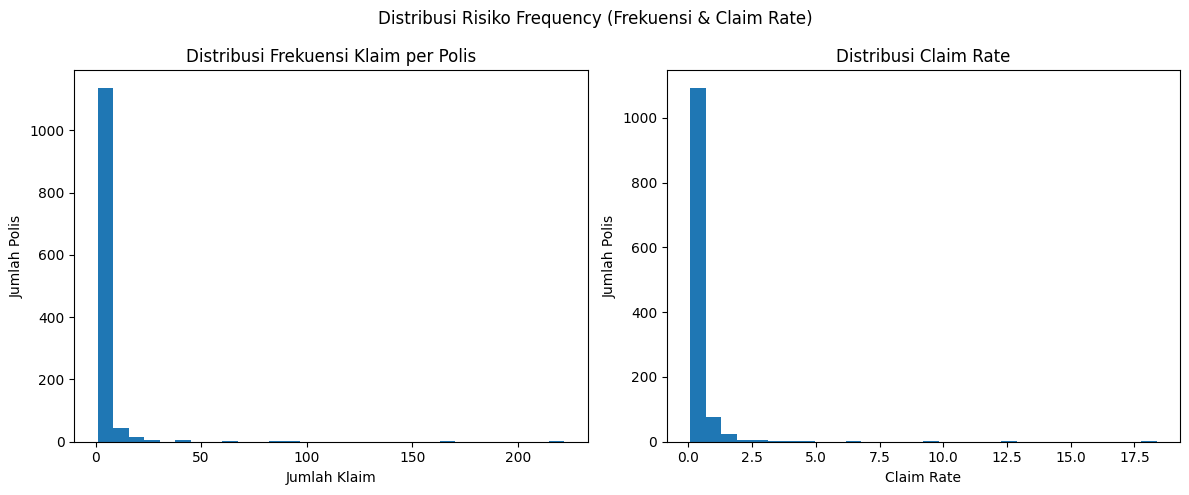

In [250]:
# Visualisasi Distribusi Frekuensi & Claim Rate
plt.figure(figsize=(12,5))

# Histogram Frekuensi
plt.subplot(1,2,1)
plt.hist(freq_per_polis['Frekuensi'], bins=30)
plt.title("Distribusi Frekuensi Klaim per Polis")
plt.xlabel("Jumlah Klaim")
plt.ylabel("Jumlah Polis")

# Histogram Claim Rate
plt.subplot(1,2,2)
plt.hist(freq_per_polis['Claim_Rate'], bins=30)
plt.title("Distribusi Claim Rate")
plt.xlabel("Claim Rate")
plt.ylabel("Jumlah Polis")

plt.suptitle("Distribusi Risiko Frequency (Frekuensi & Claim Rate)", fontsize=12)
plt.tight_layout()
plt.show()

In [251]:
# Oversipersion Check
mean_freq = freq_per_polis['Frekuensi'].mean()
var_freq = freq_per_polis['Frekuensi'].var()

print("Mean:", mean_freq)
print("Variance:", var_freq)

Mean: 3.8239669421487603
Variance: 93.16088085912133


In [252]:
# Heavy Claimant Check 
freq_per_polis['Claim_Rate'].quantile([0.9,0.95,0.99])
threshold = freq_per_polis['Claim_Rate'].quantile(0.99)
freq_per_polis['Heavy_Group'] = freq_per_polis['Claim_Rate'] > threshold
freq_per_polis['Heavy_Group'].value_counts()

Heavy_Group
False    1197
True       13
Name: count, dtype: int64

In [253]:
# ##### Statistical Testing (Kruskal-Wallis & Spearman Correlation)

from scipy.stats import kruskal, spearmanr

# 1. Test Plan Code
groups_plan = [g['Claim_Rate'].values for _, g in freq_per_polis.groupby('Plan_Code')
if len(g) >= 10]
h_plan, p_plan = kruskal(*groups_plan)

# 2. Test Usia
groups_usia = [g['Claim_Rate'].values for _, g in freq_per_polis.groupby('Usia')]
h_usia, p_usia = kruskal(*groups_usia)

# 3. Test Domisili (hanya grup >10 polis)
groups_dom = [g['Claim_Rate'].values for _, g in freq_per_polis.groupby('Domisili') if len(g) >= 10]
if len(groups_dom) >= 2:
    h_dom, p_dom = kruskal(*groups_dom)
else:
    p_dom = 1.0

# 4. Test Tenure Polis (numerik)
valid_tenure = freq_per_polis[['Tenure_Polis', 'Claim_Rate']].dropna()
r_tenure, p_tenure = spearmanr(valid_tenure['Tenure_Polis'], valid_tenure['Claim_Rate'])

# 5. Test ICD Diagnosis
valid_icd = freq_per_polis[['Jumlah_ICD_Unik', 'Claim_Rate']].dropna()
r_icd, p_icd = spearmanr(valid_icd['Jumlah_ICD_Unik'], valid_icd['Claim_Rate'])


# Ranking faktor berdasarkan p-value
faktor_data = {
    'Faktor': ['Plan Code', 'Usia', 'Domisili', 'Tenure Polis', 'Jumlah ICD Unik'],
    'P_Value': [p_plan, p_usia, p_dom, p_tenure, p_icd]
}
df_ranking = pd.DataFrame(faktor_data)
df_ranking['Signifikan'] = df_ranking['P_Value'] < 0.05
df_ranking = df_ranking.sort_values('P_Value')

print("RANKING FAKTOR PENGARUH TERHADAP FREKUENSI KLAIM")
print(df_ranking.to_string(index=False))


RANKING FAKTOR PENGARUH TERHADAP FREKUENSI KLAIM
         Faktor       P_Value  Signifikan
Jumlah ICD Unik 3.037100e-204        True
      Plan Code  5.315292e-14        True
   Tenure Polis  8.966353e-13        True
           Usia  3.236285e-01       False
       Domisili  8.116156e-01       False


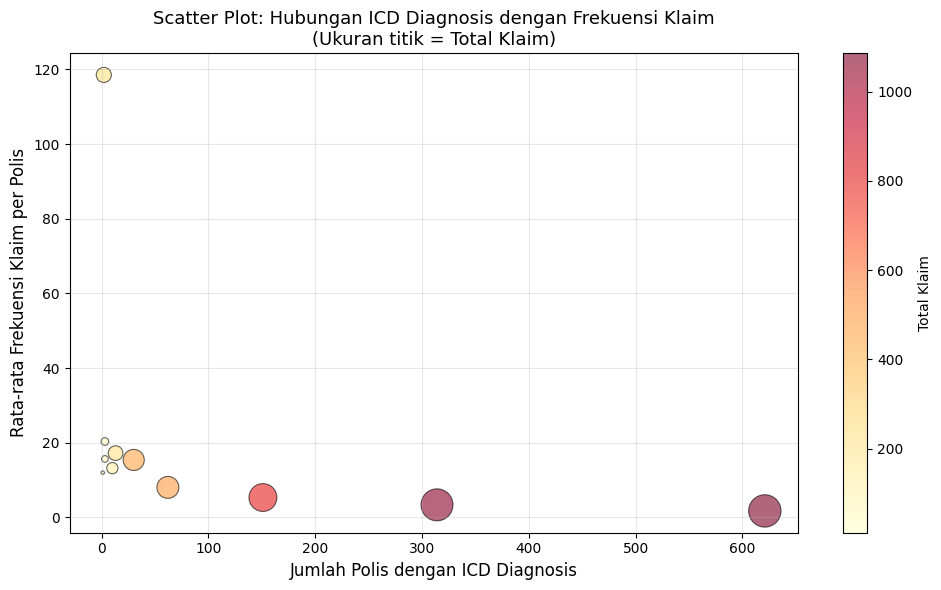

In [254]:
# VISUALISASI: Scatter Plot ICD Diagnosis vs Frekuensi Klaim 

# Buat dataframe untuk visualisasi scatter plot ICD
icd_frequency_stats = freq_per_polis.groupby('Jumlah_ICD_Unik').agg(
    Rata_Rata_Frekuensi = ('Frekuensi', 'mean'),
    Jumlah_Polis = ('Nomor Polis', 'count'),
    Total_Klaim = ('Frekuensi', 'sum')
).reset_index()

# Scatter Plot: Jumlah Polis vs Rata-rata Frekuensi Klaim
plt.figure(figsize=(10, 6))
plt.scatter(icd_frequency_stats['Jumlah_Polis'], 
           icd_frequency_stats['Rata_Rata_Frekuensi'],
           s=icd_frequency_stats['Total_Klaim']/2, 
           alpha=0.6, 
           c=icd_frequency_stats['Total_Klaim'],
           cmap='YlOrRd',
           edgecolors='black',
           linewidth=0.8)

plt.xlabel('Jumlah Polis dengan ICD Diagnosis', fontsize=12)
plt.ylabel('Rata-rata Frekuensi Klaim per Polis', fontsize=12)
plt.title('Scatter Plot: Hubungan ICD Diagnosis dengan Frekuensi Klaim\n(Ukuran titik = Total Klaim)', 
          fontsize=13)
plt.colorbar(label='Total Klaim')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Faktor Pengaruh Frekuensi Klaim
Ranking Faktor (berdasarkan p-value):
1. ICD Diagnosis (Paling Signifikan) : Polis dengan diagnosis tertentu (seperti penyakit ginjal kronis N18.0, kanker kolorektal C19) mengajukan klaim 50-160 kali lebih sering 
2. Plan Code (Signifikan): Jenis plan asuransi memberikan perbedaan signifikan pada frekuensi klaim 
3. Tenure Polis (signifikan) : Masa kepesertaan yang lebih lama berkorelasi dengan peningkatan frekuensi klaim. Hal ini dapat mencerminkan akumulasi risiko atau peningkatan pemanfaatan layanan kesehatan seiring waktu.
4. Usia (Pengaruh Terbatas) : Meskipun terdapat perbedaan pola klaim antar kelompok usia, pengaruhnya relatif lebih lemah dibanding faktor diagnosis dan plan.

Sebagian besar diagnosis (>85%) memiliki frekuensi rata-rata 1-5 klaim per polis, tetapi ada diagnosis khusus yang menjadi outlier dan membutuhkan perhatian khusus dalam risk pricing.


#### 3B. Severity Analysis 

In [255]:
# Fokus pada Analisis Severity (Biaya Klaim)
df_EDA_sev = df_final.copy()

# Feature Engineering
df_EDA_sev['Usia'] = (df_EDA_sev['Tanggal Pasien Masuk RS'] - df_EDA_sev['Tanggal Lahir']).dt.days / 365

df_EDA_sev['Durasi_Rawat'] = (
    df_EDA_sev['Tanggal Pasien Keluar RS'] - df_EDA_sev['Tanggal Pasien Masuk RS']
).dt.days

# Drop nilai aneh
df_EDA_sev = df_EDA_sev[df_EDA_sev['Durasi_Rawat'] >= 0]

In [256]:
# Kolom yang akan digunakan untuk analisis severity
cols_severity = [
    'Usia',
    'Durasi_Rawat',
    'Gender',
    'Inpatient/Outpatient',
    'Plan Code',
    'Domisili',
    'Nominal Biaya RS Yang Terjadi'
]

df_EDA_sev = df_EDA_sev[cols_severity]

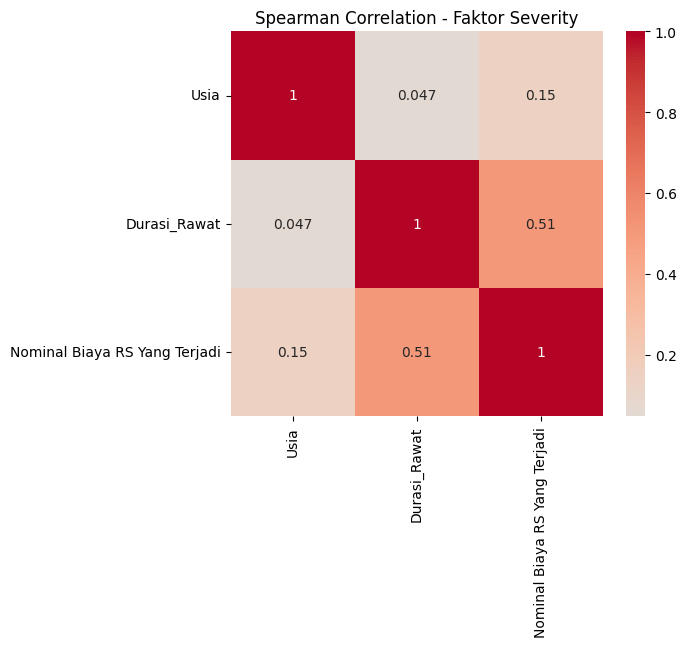

In [257]:
# Fokus pada korelasi faktor numerik dengan biaya (severity)
df_numeric = df_EDA_sev[['Usia', 'Durasi_Rawat', 'Nominal Biaya RS Yang Terjadi']]
corr_spearman = df_numeric.corr(method='spearman')

# Visualisasi Heatmap Korelasi Spearman
plt.figure(figsize=(6,5))
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', center=0)
plt.title("Spearman Correlation - Faktor Severity")
plt.show()

In [258]:
# Analisis Kategori Inpatient/Outpatient
df_EDA_sev['Inpatient/Outpatient'] = (
    df_EDA_sev['Inpatient/Outpatient']
    .str.strip()
    .str.upper()
)

# Mapping ke kategori utama
df_EDA_sev['Tipe_Rawat'] = df_EDA_sev['Inpatient/Outpatient'].replace({
    'IP': 'INPATIENT',
    'INPATIENT': 'INPATIENT',
    'ODC': 'INPATIENT',
    'ODS': 'INPATIENT',
    'OP': 'OUTPATIENT',
    'OUTPATIENT': 'OUTPATIENT'
})

df_EDA_sev['Tipe_Rawat'].value_counts()
df_EDA_sev.groupby('Tipe_Rawat')['Nominal Biaya RS Yang Terjadi'].mean()

Tipe_Rawat
INPATIENT     8.630210e+07
OUTPATIENT    2.434379e+07
Name: Nominal Biaya RS Yang Terjadi, dtype: float64

In [259]:
df_EDA_sev.groupby('Gender')['Nominal Biaya RS Yang Terjadi'].mean()  

Gender
F    5.824803e+07
M    6.167074e+07
Name: Nominal Biaya RS Yang Terjadi, dtype: float64

In [260]:
df_EDA_sev.groupby('Domisili')['Nominal Biaya RS Yang Terjadi'].agg(['mean','median','count'])

,mean,median,count
Domisili,,,
BALI,1.555558e+08,1.555558e+08,2
BALIKPAPAN,6.025362e+07,3.824522e+07,182
BANDUNG,8.587661e+07,1.553541e+07,115
BLITAR,9.068322e+06,9.817398e+06,10
JAKARTA,5.967180e+07,1.508571e+07,1296
JEMBER,2.514094e+07,1.378500e+07,44
KUDUS,1.036388e+07,2.464132e+06,3
MAKASSAR,8.142121e+07,2.373170e+07,203
MALANG,9.512679e+07,2.829775e+07,30


Faktor yang Paling Mempengaruhi Severity Klaim

1. Durasi Rawat
- Memiliki korelasi positif moderat dengan severity (ρ = 0,51).
- Semakin lama pasien dirawat, semakin tinggi biaya klaim.
2. Tipe Perawatan (Inpatient vs Outpatient)
- Rata-rata biaya rawat inap (86 juta) sekitar 3–4 kali lebih tinggi dibanding rawat jalan (24 juta).
- Menunjukkan bahwa jenis perawatan merupakan determinan utama dalam perbedaan tingkat keparahan biaya.
3. Usia
- Korelasi positif lemah (ρ = 0,15).
- Berpengaruh, namun kontribusinya relatif kecil dibanding durasi rawat.
4. Gender
- Perbedaan rata-rata biaya antara laki-laki dan perempuan relatif kecil.
- Tidak menunjukkan pengaruh yang signifikan secara praktis terhadap severity.
5. Domisili
- Terdapat variasi rata-rata antar kota, namun median antar kota besar relatif serupa.
- Pengaruhnya lebih lemah dibanding faktor klinis seperti durasi dan tipe perawatan.

Faktor yang paling konsisten dan kuat memengaruhi severity klaim adalah durasi rawat dan tipe perawatan, sedangkan faktor demografis dan geografis menunjukkan pengaruh yang lebih terbatas.

### 4. Preprocessing - Encoding & Normalisasi

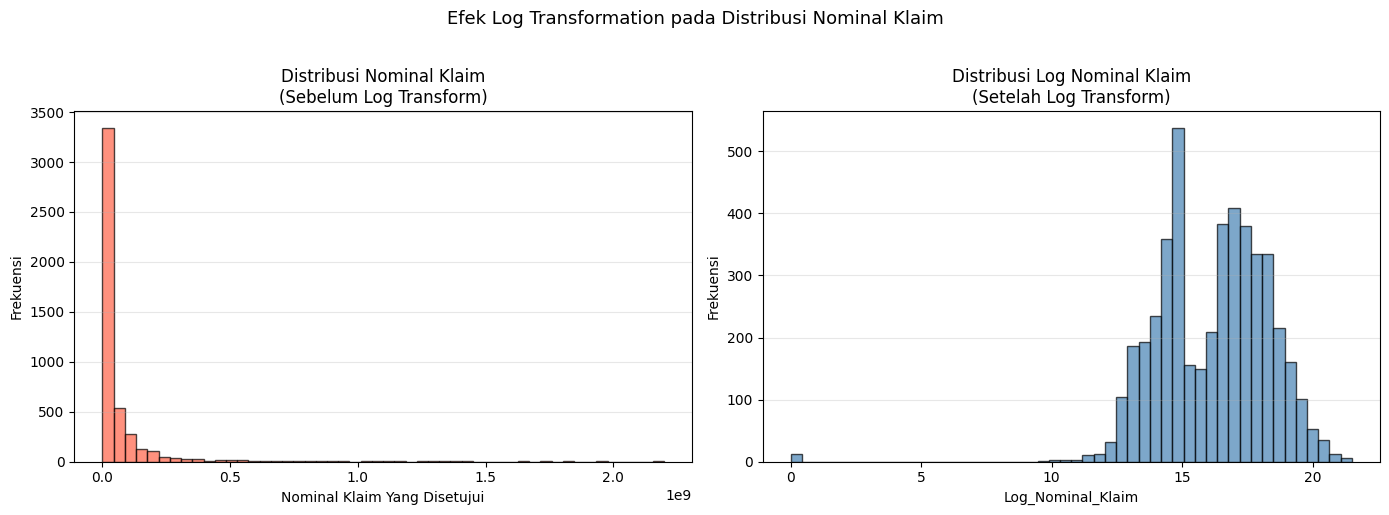

In [261]:
from sklearn.preprocessing import LabelEncoder

# A. Log Transformation untuk Target Variable (Mengatasi Outlier/Skewness)
#  buat kolom target baru yg sudah dinormalisasi
df_final['Log_Nominal_Klaim'] = np.log1p(df_final['Nominal Klaim Yang Disetujui'])

# B. Label Encoding (Mengubah Kategori jadi Angka 0, 1, 2...)
cols_to_encode = ['Gender', 'Plan Code', 'Inpatient/Outpatient', 'Reimburse/Cashless', 'Kategori_Usia', 'Domisili']
le = LabelEncoder()

for col in cols_to_encode:
    # Convert ke string utk jaga-jaga ada tipe campuran
    df_final[col] = le.fit_transform(df_final[col].astype(str))

# C. Frequency Encoding untuk ICD Diagnosis
# Karena kodenya banyak, ganti dengan "seberapa sering muncul"
icd_freq = df_final['ICD Diagnosis'].value_counts(normalize=True)
df_final['ICD_Encoded'] = df_final['ICD Diagnosis'].map(icd_freq)

plt.figure(figsize=(14, 5))
# Sebelum Log Transform
plt.subplot(1, 2, 1)
plt.hist(df_final['Nominal Klaim Yang Disetujui'].dropna(),
         bins=50, color='tomato', edgecolor='black', alpha=0.7)
plt.title('Distribusi Nominal Klaim\n(Sebelum Log Transform)')
plt.xlabel('Nominal Klaim Yang Disetujui')
plt.ylabel('Frekuensi')
plt.grid(axis='y', alpha=0.3)

# Sesudah Log Transform
plt.subplot(1, 2, 2)
plt.hist(df_final['Log_Nominal_Klaim'].dropna(),
         bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribusi Log Nominal Klaim\n(Setelah Log Transform)')
plt.xlabel('Log_Nominal_Klaim')
plt.ylabel('Frekuensi')
plt.grid(axis='y', alpha=0.3)

plt.suptitle('Efek Log Transformation pada Distribusi Nominal Klaim',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### 4.1 Data Transformation - Log Transform & Encoding

In [262]:
# Hapus kolom yang tidak dipakai model (tanggal mentah, ID unik)
cols_drop = ['Claim ID', 'Nomor Polis', 'Tanggal Lahir', 'Tanggal Pasien Masuk RS',
             'Tanggal Pasien Keluar RS', 'Tanggal Pembayaran Klaim',
             'ICD Diagnosis', 'ICD Description', 'Bulan_Tahun', 'Lokasi RS', 'Status Klaim', 
             'Nominal Biaya RS Yang Terjadi', 'Tanggal Efektif Polis']

# Dataset Final Siap Training
X_ready = df_final.drop(columns=cols_drop + ['Nominal Klaim Yang Disetujui', 'Log_Nominal_Klaim'])
y_ready = df_final['Log_Nominal_Klaim'] # Gunakan Log target untuk training

print("Dimensi Data Siap Pakai:", X_ready.shape)
print(X_ready.head())

Dimensi Data Siap Pakai: (4627, 13)
   Reimburse/Cashless  Inpatient/Outpatient  Plan Code  Gender  Domisili  \
0                   1                     4          0       0         4   
1                   1                     4          1       1        19   
2                   1                     4          1       0        17   
3                   1                     4          1       0        17   
4                   1                     4          1       0         4   

   Usia  Durasi_Rawat  Bulan  Tahun  Kuartal  Kategori_Usia  Tenure_Polis  \
0    57             0      5   2024        2              1           114   
1    67             0      7   2024        3              2           146   
2    64             0      5   2024        2              2           111   
3    64             0      7   2024        3              2           113   
4    55             0      6   2024        2              1           121   

   ICD_Encoded  
0     0.054895  
1     0.02

### 5. Model Training & Prediction

Pilihan Model:
1. CatBoost Regressor
Kenapa: Dataset penuh dengan fitur kategorikal (Gender, Plan Code, ICD Diagnosis, Domisili). CatBoost dapat memproses data kategorikal ini secara otomatis tanpa perlu One-Hot Encoding yang rumit.

    Kegunaan: Sangat akurat untuk memprediksi Severity (keparahan klaim) berdasarkan diagnosis (ICD) dan Frequency berdasarkan profil demografis, karena ia menangani variasi kategori dengan sangat baik.

2. XGBoost (Extreme Gradient Boosting)
Kenapa: Model standar industri untuk kompetisi Kaggle pada data tabular. XGBoost memiliki penanganan missing value bawaan dan regularization yang kuat untuk mencegah overfitting pada dataset yang relatif kecil (4096 polis).

    Kegunaan: Efektif untuk memprediksi Total Claim. XGBoost juga menyediakan fitur feature importance untuk menjawab tujuan bisnis: "mengetahui faktor yang paling berpengaruh terhadap nilai klaim."

3. Prophet (by Meta)
Kenapa: Karena tujuan akhirnya adalah memprediksi Trend (Agustus - Desember 2025), Prophet didesain khusus untuk Time Series Forecasting. Model ini tangguh menangani seasonality (pola musiman) dan holiday effects (misal: lonjakan klaim pasca libur).

    Kegunaan: Digunakan khusus untuk memproyeksikan tren Frequency dan Total Claim per bulan ke depan dengan memperhitungkan pola historis kenaikan 25.5% yang disebutkan dalam soal.

### 6. Evaluasi & Interpretasi Model

### 7. Kesimpulan & Rekomendasi Bisnis